# **ES 335 - Machine Learning Assignment 4**

**Name: Niraj Kumar**

**Roll: 24110222**

# Question 1

Multi-Layer Perceptron (MLP):
- Load the CIFAR-10 dataset using PyTorch. Normalize the images and visualize a few samples
along with their labels. Flatten each image into a vector of size 3072.
- Implement an MLP with at least two hidden layers. Use ReLU activation and softmax output.
Train the model using cross-entropy loss.
- Plot training and validation accuracy versus epochs. Plot training loss versus epochs. Report final
test accuracy.
- Vary the number of hidden layers and number of neurons. Plot accuracy as a function of model
capacity. Comment on overfitting and underfitting behavior.
- Visualize the flattened image as a 1D vector. Randomly shuffle pixels in the input images and
retrain the model. Compare performance before and after shuffling.
- Visualize misclassified images.

**Loading and Normalizing CIFAR-10 dataset**

In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# Data Transforms
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.5, 0.5, 0.5), # mean
(0.5, 0.5, 0.5)) # std
])

In [ ]:
# Load CIFAR-10 Dataset
trainset = torchvision.datasets.CIFAR10(
  root='./data',
  train=True,
  download=True,
  transform=transform
)

testset = torchvision.datasets.CIFAR10(
  root='./data',
  train=False,
  download=True,
  transform=transform
)

100%|██████████| 170M/170M [00:02<00:00, 78.0MB/s]


In [ ]:
# Data Loaders
trainloader = torch.utils.data.DataLoader(
  trainset,
  batch_size=128,
  shuffle=True,
  num_workers=2
)

testloader = torch.utils.data.DataLoader(
  testset,
  batch_size=128,
  shuffle=False,
  num_workers=2
)

In [ ]:
# Class Names
classes = ('plane', 'car', 'bird', 'cat',
            'deer', 'dog', 'frog', 'horse',
            'ship', 'truck')

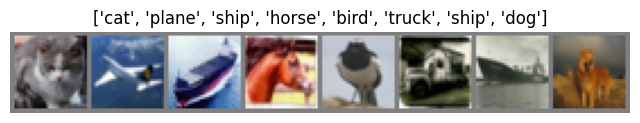

In [ ]:
# Visualize Sample Images

def imshow(img):
  img = img / 2 + 0.5 # unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.axis('off')

# get random batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
plt.figure(figsize=(8, 4))
imshow(torchvision.utils.make_grid(images[:8]))
plt.title([classes[labels[j]] for j in range(8)])
plt.show()

**Implementing the Multi Layer Perceptron (MLP)**

In [ ]:
import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self, hidden_sizes=[512, 256]):
        super(MLP, self).__init__()

        # Input size for CIFAR-10 is 3 * 32 * 32 = 3072
        layers = []
        input_size = 3072

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size

        # Final output layer for 10 classes
        layers.append(nn.Linear(input_size, 10))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Flattening the image: (batch_size, 3, 32, 32) -> (batch_size, 3072)
        x = x.view(x.size(0), -1)
        return self.network(x)

# Initializing model, loss function and optimizer
mlp_model = MLP(hidden_sizes=[512, 256]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

**Training Loop, Plotting, and Testing**

Training Base MLP
Epoch 1/15 - Loss: 1.6289 - Train Acc: 42.24% - Val Acc: 47.86%
Epoch 2/15 - Loss: 1.4109 - Train Acc: 50.31% - Val Acc: 49.56%
Epoch 3/15 - Loss: 1.2941 - Train Acc: 54.20% - Val Acc: 51.50%
Epoch 4/15 - Loss: 1.2028 - Train Acc: 57.70% - Val Acc: 52.42%
Epoch 5/15 - Loss: 1.1162 - Train Acc: 60.57% - Val Acc: 54.13%
Epoch 6/15 - Loss: 1.0344 - Train Acc: 63.48% - Val Acc: 53.71%
Epoch 7/15 - Loss: 0.9552 - Train Acc: 66.08% - Val Acc: 54.34%
Epoch 8/15 - Loss: 0.8708 - Train Acc: 69.03% - Val Acc: 53.96%
Epoch 9/15 - Loss: 0.8008 - Train Acc: 71.53% - Val Acc: 54.22%
Epoch 10/15 - Loss: 0.7308 - Train Acc: 74.34% - Val Acc: 53.06%
Epoch 11/15 - Loss: 0.6585 - Train Acc: 76.35% - Val Acc: 53.91%
Epoch 12/15 - Loss: 0.5921 - Train Acc: 78.79% - Val Acc: 54.39%
Epoch 13/15 - Loss: 0.5332 - Train Acc: 81.04% - Val Acc: 53.52%
Epoch 14/15 - Loss: 0.4817 - Train Acc: 82.80% - Val Acc: 54.00%
Epoch 15/15 - Loss: 0.4416 - Train Acc: 84.24% - Val Acc: 53.30%


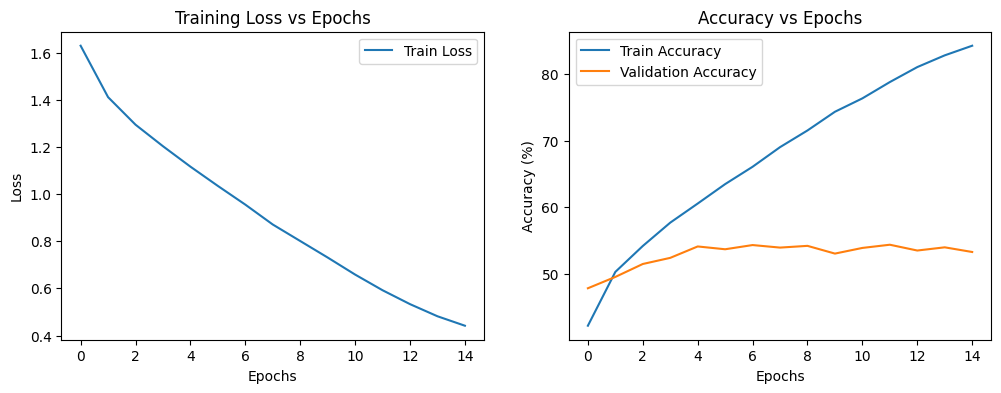

Final Test Accuracy: 53.30%


In [ ]:
def train_and_evaluate(model, trainloader, testloader, criterion, optimizer, epochs=15, pixel_shuffle_perm=None):
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            # we will apply pixel shuffling if a permutation is provided
            if pixel_shuffle_perm is not None:
                images = images.view(images.size(0), -1)
                images = images[:, pixel_shuffle_perm]
                images = images.view(images.size(0), 3, 32, 32)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(trainloader))
        train_accuracies.append(100 * correct_train / total_train)

        # Validation
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)

                if pixel_shuffle_perm is not None:
                    images = images.view(images.size(0), -1)
                    images = images[:, pixel_shuffle_perm]
                    images = images.view(images.size(0), 3, 32, 32)

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_accuracies.append(100 * correct_val / total_val)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f} - Train Acc: {train_accuracies[-1]:.2f}% - Val Acc: {val_accuracies[-1]:.2f}%")

    return train_losses, train_accuracies, val_accuracies

# Training the base MLP
print("Training Base MLP")
train_losses, train_accs, val_accs = train_and_evaluate(mlp_model, trainloader, testloader, criterion, optimizer, epochs=15)

# Plotting
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

print(f"Final Test Accuracy: {val_accs[-1]:.2f}%")

**Model Capacity, Overfitting and Underfitting**


Training Model A (Small) [32]
Epoch 1/10 - Loss: 1.7053 - Train Acc: 39.83% - Val Acc: 44.14%
Epoch 2/10 - Loss: 1.5477 - Train Acc: 45.67% - Val Acc: 45.90%
Epoch 3/10 - Loss: 1.4847 - Train Acc: 47.71% - Val Acc: 47.05%
Epoch 4/10 - Loss: 1.4443 - Train Acc: 49.10% - Val Acc: 47.76%
Epoch 5/10 - Loss: 1.4149 - Train Acc: 50.14% - Val Acc: 47.66%
Epoch 6/10 - Loss: 1.3917 - Train Acc: 50.90% - Val Acc: 47.16%
Epoch 7/10 - Loss: 1.3729 - Train Acc: 51.71% - Val Acc: 47.83%
Epoch 8/10 - Loss: 1.3530 - Train Acc: 52.48% - Val Acc: 47.71%
Epoch 9/10 - Loss: 1.3421 - Train Acc: 52.85% - Val Acc: 48.57%
Epoch 10/10 - Loss: 1.3245 - Train Acc: 53.43% - Val Acc: 48.27%

Training Model B (Medium) [512, 256]
Epoch 1/10 - Loss: 1.6238 - Train Acc: 42.29% - Val Acc: 47.89%
Epoch 2/10 - Loss: 1.4056 - Train Acc: 50.44% - Val Acc: 50.59%
Epoch 3/10 - Loss: 1.2959 - Train Acc: 54.12% - Val Acc: 51.84%
Epoch 4/10 - Loss: 1.2008 - Train Acc: 57.67% - Val Acc: 52.53%
Epoch 5/10 - Loss: 1.1141 - Train 

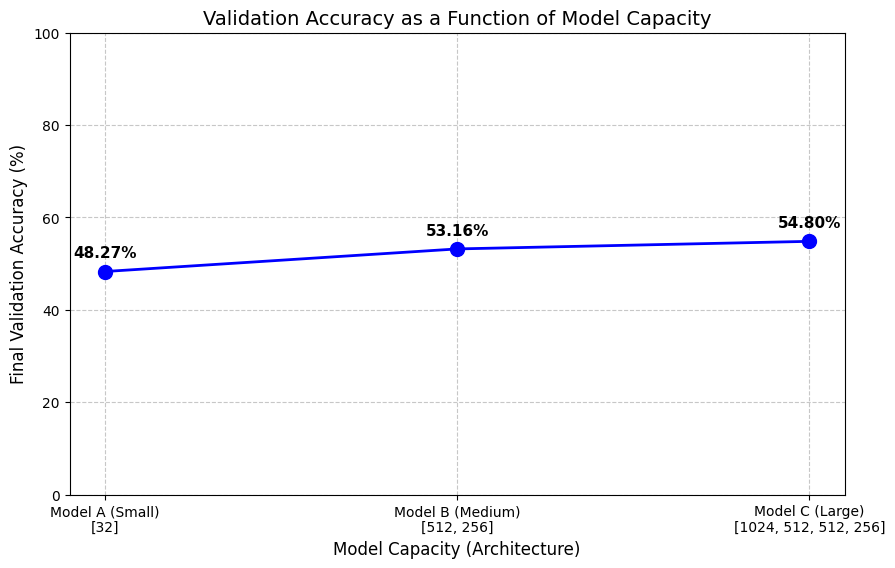

In [ ]:
capacities = {
    "Model A (Small)\n[32]": [32],
    "Model B (Medium)\n[512, 256]": [512, 256],
    "Model C (Large)\n[1024, 512, 512, 256]": [1024, 512, 512, 256]
}

capacity_results = {}

for name, hidden_sizes in capacities.items():
    print(f"\nTraining {name.replace(chr(10), ' ')}")

    model = MLP(hidden_sizes=hidden_sizes).to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)

    _, _, val_accs = train_and_evaluate(model, trainloader, testloader, criterion, opt, epochs=10)

    capacity_results[name] = val_accs[-1]

# Plotting
model_names = list(capacity_results.keys())
final_accuracies = list(capacity_results.values())

plt.figure(figsize=(10, 6))
plt.plot(model_names, final_accuracies, marker='o', markersize=10, linestyle='-', color='blue', linewidth=2)

plt.title('Validation Accuracy as a Function of Model Capacity', fontsize=14)
plt.xlabel('Model Capacity (Architecture)', fontsize=12)
plt.ylabel('Final Validation Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 100)

for i, acc in enumerate(final_accuracies):
    plt.text(i, acc + 3, f"{acc:.2f}%", ha='center', fontsize=11, fontweight='bold')

plt.show()

**Underfitting (Low Capacity Model):** A model with only a few neurons (e.g., one layer of 32) demonstrates underfitting. We know this because the training accuracy remains exceptionally low(53.43%). The model simply lacks the architectural capacity (parameters) to capture the complex underlying patterns in the CIFAR-10 images.

**Overfitting (High Capacity Model):** A very deep model(1024, 512, 512, 256) demonstrates overfitting because the network has achieved near perfect training accuracy(74.48%), but the validation accuracy has not changed much (i.e. stalled) as epoch increased or it might degrade if we increase more epochs, meaning it is memorizing the training data rather than generalizing.

**Pixel Shuffling Experiment**

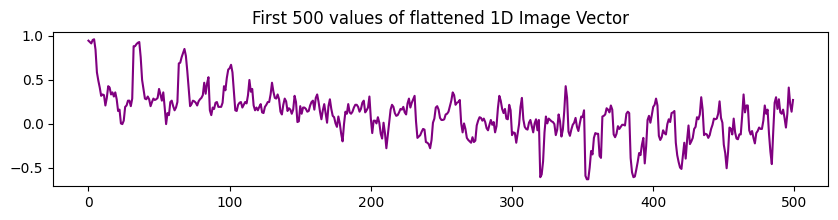


Retraining with Shuffled Pixels
Epoch 1/10 - Loss: 1.6315 - Train Acc: 41.95% - Val Acc: 48.20%
Epoch 2/10 - Loss: 1.4100 - Train Acc: 50.42% - Val Acc: 50.18%
Epoch 3/10 - Loss: 1.2927 - Train Acc: 54.43% - Val Acc: 52.15%
Epoch 4/10 - Loss: 1.1970 - Train Acc: 57.63% - Val Acc: 52.49%
Epoch 5/10 - Loss: 1.1108 - Train Acc: 60.74% - Val Acc: 54.26%
Epoch 6/10 - Loss: 1.0269 - Train Acc: 63.52% - Val Acc: 53.55%
Epoch 7/10 - Loss: 0.9468 - Train Acc: 66.39% - Val Acc: 54.22%
Epoch 8/10 - Loss: 0.8740 - Train Acc: 68.68% - Val Acc: 53.68%
Epoch 9/10 - Loss: 0.7966 - Train Acc: 71.66% - Val Acc: 53.16%
Epoch 10/10 - Loss: 0.7264 - Train Acc: 74.18% - Val Acc: 53.42%
Accuracy BEFORE Shuffling (Original Images): 54.80%
Accuracy AFTER Shuffling (Scrambled Images): 53.42%


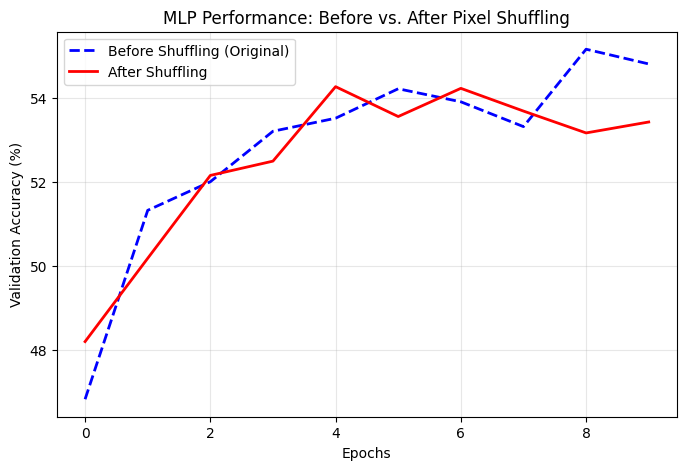

In [ ]:
# Visualizing the flattened image as a 1D vector
sample_image, _ = next(iter(trainloader))
flat_image = sample_image[0].view(-1).numpy()

plt.figure(figsize=(10, 2))

# Plotting a subset of the 3072 vector for visibility
plt.plot(flat_image[:500], color='purple')
plt.title("First 500 values of flattened 1D Image Vector")
plt.show()

# Randomly shuffling pixels
print("\nRetraining with Shuffled Pixels")

shuffle_perm = torch.randperm(3072)

shuffle_model = MLP(hidden_sizes=[512, 256]).to(device)
shuffle_opt = optim.Adam(shuffle_model.parameters(), lr=0.001)

# Training the shuffled model
_, _, shuffled_val_accs = train_and_evaluate(
    shuffle_model, trainloader, testloader, criterion, shuffle_opt,
    epochs=10, pixel_shuffle_perm=shuffle_perm
)

base_accuracy = val_accs[9]
shuffled_accuracy = shuffled_val_accs[-1]

print(f"Accuracy BEFORE Shuffling (Original Images): {base_accuracy:.2f}%")
print(f"Accuracy AFTER Shuffling (Scrambled Images): {shuffled_accuracy:.2f}%")

# Plotting the comparison
plt.figure(figsize=(8, 5))

plt.plot(val_accs[:10], label='Before Shuffling (Original)', linestyle='--', color='blue', linewidth=2)
plt.plot(shuffled_val_accs, label='After Shuffling', color='red', linewidth=2)
plt.title('MLP Performance: Before vs. After Pixel Shuffling')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Visualizing Misclassified Images**

Format -> True Label | Predicted Label
T:cat | P:deer   T:ship | P:car   T:ship | P:plane   T:plane | P:horse   T:frog | P:deer   T:dog | P:car   T:truck | P:car   T:dog | P:cat


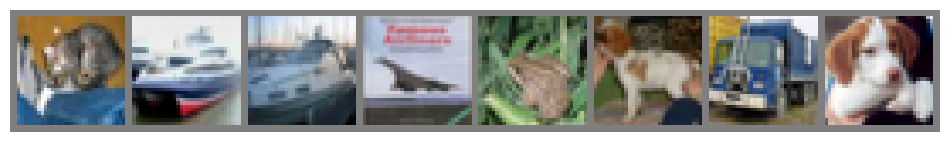

In [ ]:
def show_misclassified(model, testloader, classes):
    model.eval()
    misclassified_images = []
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            # Finding mismatches
            mismatches = (predicted != labels)
            for i in range(len(mismatches)):
                if mismatches[i] and len(misclassified_images) < 8:
                    misclassified_images.append(images[i].cpu())
                    true_labels.append(labels[i].cpu().item())
                    predicted_labels.append(predicted[i].cpu().item())

            if len(misclassified_images) >= 8:
                break

    plt.figure(figsize=(12, 6))
    grid = torchvision.utils.make_grid(misclassified_images)
    imshow(grid)

    titles = [f"T:{classes[t]} | P:{classes[p]}" for t, p in zip(true_labels, predicted_labels)]
    print("Format -> True Label | Predicted Label")
    print("   ".join(titles))

show_misclassified(mlp_model, testloader, classes)

# Question 2

Convolutional Neural Network (CNN):
- Implement a CNN using convolutional layers, ReLU activations, and pooling layers (stride as 2).
Use fully connected layers at the end for classification. Train the model using cross-entropy loss.
- Plot training and validation accuracy versus epochs. Plot training loss versus epochs. Report final
test accuracy. Compare the performance with the MLP model.
- Visualize feature maps from different convolutional layers for a few input images. Observe how
features evolve across layers.
- Apply small translations or shifts to input images and evaluate the performance of both MLP and
CNN. Compare the robustness of the two models (you can show this experiment in the previous
question for MLP).
- Remove pooling layers and observe performance changes.

**Implementing the Convolutional Neural Network (CNN)**

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Input: 3 x 32 x 32
        # Layer 1: Conv -> ReLU -> MaxPool
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 32 x 16 x 16

        # Layer 2: Conv -> ReLU -> MaxPool
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 64 x 8 x 8

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        # Flattenning for the fully connected layer
        x = x.view(x.size(0), -1)

        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# Initializing CNN
cnn_model = CNN().to(device)
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

**Training the CNN and Comparing with MLP**

Training CNN
Epoch 1/15 - Loss: 1.3722 - Train Acc: 50.89% - Val Acc: 58.48%
Epoch 2/15 - Loss: 0.9751 - Train Acc: 65.42% - Val Acc: 67.14%
Epoch 3/15 - Loss: 0.7883 - Train Acc: 72.45% - Val Acc: 71.50%
Epoch 4/15 - Loss: 0.6430 - Train Acc: 77.49% - Val Acc: 71.43%
Epoch 5/15 - Loss: 0.5039 - Train Acc: 82.58% - Val Acc: 73.17%
Epoch 6/15 - Loss: 0.3689 - Train Acc: 87.63% - Val Acc: 73.86%
Epoch 7/15 - Loss: 0.2447 - Train Acc: 91.71% - Val Acc: 72.61%
Epoch 8/15 - Loss: 0.1490 - Train Acc: 95.27% - Val Acc: 72.02%
Epoch 9/15 - Loss: 0.0927 - Train Acc: 97.22% - Val Acc: 72.25%
Epoch 10/15 - Loss: 0.0596 - Train Acc: 98.27% - Val Acc: 73.53%
Epoch 11/15 - Loss: 0.0521 - Train Acc: 98.37% - Val Acc: 72.54%
Epoch 12/15 - Loss: 0.0517 - Train Acc: 98.39% - Val Acc: 71.99%
Epoch 13/15 - Loss: 0.0523 - Train Acc: 98.29% - Val Acc: 72.32%
Epoch 14/15 - Loss: 0.0477 - Train Acc: 98.40% - Val Acc: 72.20%
Epoch 15/15 - Loss: 0.0461 - Train Acc: 98.47% - Val Acc: 72.25%


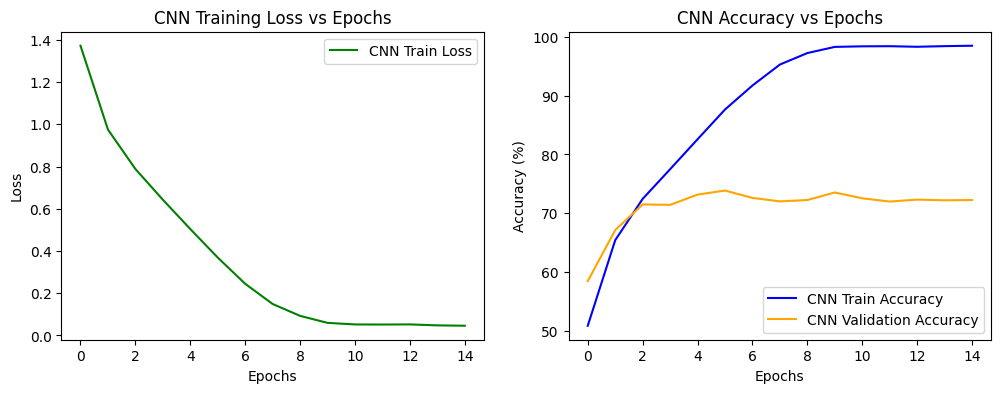

Final CNN Test Accuracy: 72.25%


In [ ]:
print("Training CNN")
cnn_train_losses, cnn_train_accs, cnn_val_accs = train_and_evaluate(
    cnn_model, trainloader, testloader, cnn_criterion, cnn_optimizer, epochs=15
)

# Plotting CNN Results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_train_losses, label='CNN Train Loss', color='green')
plt.title('CNN Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_train_accs, label='CNN Train Accuracy', color='blue')
plt.plot(cnn_val_accs, label='CNN Validation Accuracy', color='orange')
plt.title('CNN Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

print(f"Final CNN Test Accuracy: {cnn_val_accs[-1]:.2f}%")

**Comparison with MLP:**

 CNN achieved a significantly higher test accuracy (72.25% in this case) as compared to the MLP (53.30%). The CNN converges faster and generalizes better because it leverages spatial hierarchies (edges, shapes) instead of treating every pixel independently like the MLP does.

**Visualizing Feature Maps**

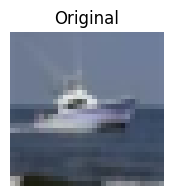

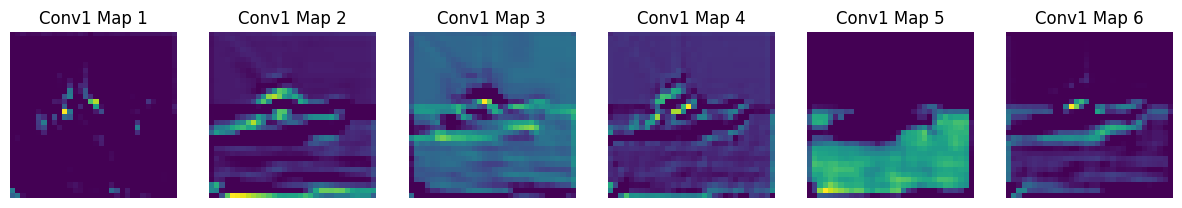

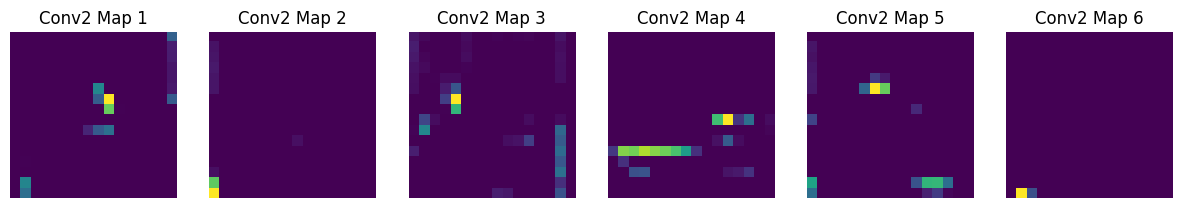

In [ ]:
def visualize_feature_maps(model, image_tensor):
    model.eval()
    with torch.no_grad():
        # Add batch dimension and move to device
        x = image_tensor.unsqueeze(0).to(device)

        # Passing through Conv1 + ReLU
        out1 = model.relu1(model.conv1(x))
        # Passing through Pool1 + Conv2 + ReLU
        out2 = model.relu2(model.conv2(model.pool1(out1)))

    # Convert back to CPU for plotting
    fm1 = out1.squeeze(0).cpu().numpy()
    fm2 = out2.squeeze(0).cpu().numpy()

    # Plotting original image
    plt.figure(figsize=(2, 2))
    imshow(image_tensor)
    plt.title("Original")
    plt.show()

    # Plotting first 6 feature maps of Layer 1
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        axes[i].imshow(fm1[i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Conv1 Map {i+1}')
    plt.show()

    # Plotting first 6 feature maps of Layer 2
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        axes[i].imshow(fm2[i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Conv2 Map {i+1}')
    plt.show()


dataiter = iter(trainloader)
images, _ = next(dataiter)
sample_img = images[0]

visualize_feature_maps(cnn_model, sample_img)

**Evaluating Robustness to Translations (Shifts)**

In [ ]:
# Defining a transform that shifts images by up to 10%
shift_transform = transforms.Compose([
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Creating a new shifted test loader
shifted_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=shift_transform)
shifted_testloader = torch.utils.data.DataLoader(shifted_testset, batch_size=128, shuffle=False, num_workers=2)

def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Assuming mlp_model of Question 1 is still in memory
mlp_shift_acc = evaluate_model(mlp_model, shifted_testloader)
cnn_shift_acc = evaluate_model(cnn_model, shifted_testloader)

print(f"MLP Accuracy on Shifted Data: {mlp_shift_acc:.2f}% (Drop from base accuracy)")
print(f"CNN Accuracy on Shifted Data: {cnn_shift_acc:.2f}% (Drop from base accuracy)")

MLP Accuracy on Shifted Data: 33.48% (Drop from base accuracy)
CNN Accuracy on Shifted Data: 54.28% (Drop from base accuracy)


**To illustrate this difference in robustness on graph I tracked model accuracy across a series of shift magnitudes (0% to 20%)**

Evaluating models across different shift amounts
Shift: 0% | MLP Acc: 53.30% | CNN Acc: 72.25%
Shift: 5% | MLP Acc: 42.37% | CNN Acc: 64.26%
Shift: 10% | MLP Acc: 33.50% | CNN Acc: 53.69%
Shift: 15% | MLP Acc: 28.73% | CNN Acc: 47.10%
Shift: 20% | MLP Acc: 24.29% | CNN Acc: 40.80%


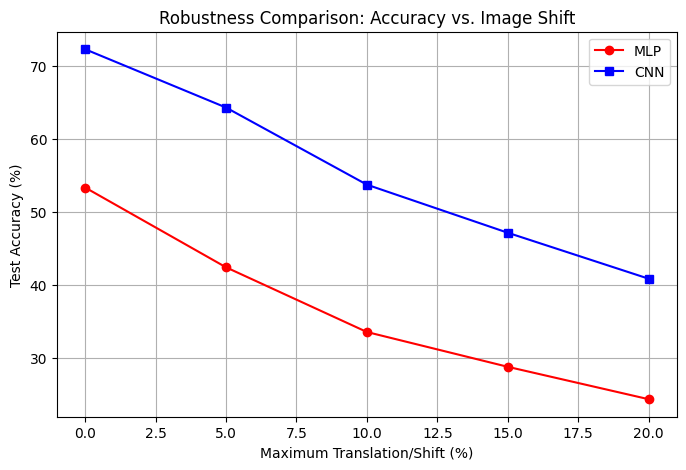

In [ ]:
# Defining the exact shifts we want to test: 0%, 5%, 10%, 15%, 20%
shift_percentages = [0.0, 0.05, 0.10, 0.15, 0.20]

mlp_shift_accuracies = []
cnn_shift_accuracies = []

print("Evaluating models across different shift amounts")

for shift in shift_percentages:
    temp_transform = transforms.Compose([
        transforms.RandomAffine(degrees=0, translate=(shift, shift)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    temp_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=temp_transform)
    temp_testloader = torch.utils.data.DataLoader(temp_testset, batch_size=128, shuffle=False, num_workers=2)

    mlp_acc = evaluate_model(mlp_model, temp_testloader)
    cnn_acc = evaluate_model(cnn_model, temp_testloader)

    mlp_shift_accuracies.append(mlp_acc)
    cnn_shift_accuracies.append(cnn_acc)

    print(f"Shift: {shift*100:.0f}% | MLP Acc: {mlp_acc:.2f}% | CNN Acc: {cnn_acc:.2f}%")

# Plotting
plt.figure(figsize=(8, 5))
x_axis_labels = [s * 100 for s in shift_percentages]

plt.plot(x_axis_labels, mlp_shift_accuracies, marker='o', linestyle='-', color='red', label='MLP')
plt.plot(x_axis_labels, cnn_shift_accuracies, marker='s', linestyle='-', color='blue', label='CNN')

plt.title('Robustness Comparison: Accuracy vs. Image Shift')
plt.xlabel('Maximum Translation/Shift (%)')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

As we can see in the graph and output logs, the CNN is significantly more robust to small translations than the MLP. At a 10% shift, the MLP's accuracy dropped sharply, whereas the CNN maintains a much higher level of performance due to the translation invariance provided by its convolutional and pooling layers.

**Removing Pooling Layers**

In [ ]:
class CNN_NoPool(nn.Module):
    def __init__(self):
        super(CNN_NoPool, self).__init__()
        # Padding=1 keeps spatial dimensions same (32x32)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()

        # Bcoz there is no pooling, the spatial size remains 32x32
        # The flattened size is: 64 channels * 32 * 32 = 65536
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

nopool_model = CNN_NoPool().to(device)
nopool_criterion = nn.CrossEntropyLoss()
nopool_optimizer = optim.Adam(nopool_model.parameters(), lr=0.001)

print("Training CNN without Pooling ")
_, _, nopool_val_accs = train_and_evaluate(
    nopool_model, trainloader, testloader, nopool_criterion, nopool_optimizer, epochs=8
)

print(f"Final Accuracy (No Pool): {nopool_val_accs[-1]:.2f}%")

Training CNN without Pooling 
Epoch 1/8 - Loss: 1.3728 - Train Acc: 51.08% - Val Acc: 58.73%
Epoch 2/8 - Loss: 0.9418 - Train Acc: 66.56% - Val Acc: 67.06%
Epoch 3/8 - Loss: 0.6856 - Train Acc: 75.99% - Val Acc: 68.02%
Epoch 4/8 - Loss: 0.4614 - Train Acc: 84.13% - Val Acc: 67.26%
Epoch 5/8 - Loss: 0.2547 - Train Acc: 91.58% - Val Acc: 67.04%
Epoch 6/8 - Loss: 0.1137 - Train Acc: 96.55% - Val Acc: 66.72%
Epoch 7/8 - Loss: 0.0574 - Train Acc: 98.46% - Val Acc: 65.81%
Epoch 8/8 - Loss: 0.0379 - Train Acc: 98.93% - Val Acc: 66.45%
Final Accuracy (No Pool): 66.45%


# Acknowledgements

The assignment, with the help of language models/AI tools, is refined for better structuring of the code and diagrams. I have also used ISLP lab code/documentation and Google colab code shared by the course TA for reference.